# **04. [Colorectal] Survival Curves**

## **Introduction**
Generation of survival curves for the machine learning survival analysis (MLSA) models, along with the predictions from the XGB classification models from the previous study. The RSF and GBSA model curves are natively produced by the models, while the SSVM curve was adapted to represent probabilities over time. No curve adaptations were found for the XGB-Cox, XGB-AFT, and LGBM models that satisfied the theoretical assumptions.

## Environment Settings

In [ ]:
# download the file that contains the requirement management functions
!gdown 1563shEptjQS10FQbqjM-QsXot_cvHJBL --quiet
%run /content/bootstrap.py

# mount google drive
from google.colab import drive
drive.mount('/content/drive')

# put here the your Drive's path to the project
LOCAL_PROJECT_PATH = "/content/drive/MyDrive/Trabalho/Câncer/ML de Sobrevida"

set_project(LOCAL_PROJECT_PATH)
setup()

Mounted at /content/drive
Projeto definido: /content/drive/MyDrive/Trabalho/Câncer/ML de Sobrevida

Grupos disponíveis:
1. data_analysis
2. ml
3. Criar novo grupo

Escolha (ex: 1,3): 2

Lendo dependências de ml:
  - cmaes==0.13.0
  - lifelines==0.30.3
  - lightgbm==4.6.0
  - matplotlib==3.10.0
  - numpy==2.0.2
  - optuna==4.8.0
  - pandas==2.2.2
  - scikit-learn==1.8.0
  - scikit-survival==0.27.0
  - scipy==1.16.3
  - shap==0.51.0
  - xgboost==3.2.0

 Instalando dependências necessárias:
 + cmaes==0.13.0
 + lifelines==0.30.3
 + optuna==4.8.0
 + scikit-learn==1.8.0
 + scikit-survival==0.27.0
 + shap==0.51.0

⚠️ Dependências instaladas.
Reiniciando o kernel automaticamente...


<IPython.core.display.Javascript object>

In [ ]:
# Imports
import os
import pickle
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib

from scipy.interpolate import interp1d

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler, MinMaxScaler, MaxAbsScaler, QuantileTransformer
from sklearn.metrics import roc_curve, roc_auc_score, auc, ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

from sksurv.ensemble import RandomSurvivalForest
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.svm import FastSurvivalSVM
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored, concordance_index_ipcw, brier_score
from sksurv.nonparametric import kaplan_meier_estimator

from lifelines.statistics import logrank_test
from lifelines import KaplanMeierFitter

import xgboost as xgb
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier

import optuna
from optuna.samplers import RandomSampler, TPESampler, CmaEsSampler

import shap

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

## Seed

In [ ]:
seed = 1

## Functions

In [ ]:
# Importing the functions
!gdown 1-uw7N4Vx5eNLso_NQ64uObFTlwXhdnda --quiet

from functions_ml_survival import *

In [ ]:
#######################################################################################

def train_preprocessing(df, ohe_encoder=None, normalizer='StandardScaler'):
    """
    Performs preprocessing on the training dataset.

    Args:
        df (pandas.DataFrame): The DataFrame to be preprocessed.
        ohe_encoder (list, optional): A list of columns to apply one-hot encoding. If None,
            all categorical columns will be encoded using LabelEncoder.
        normalizer (str, optional): The type of normalization to apply. Defaults to 'StandardScaler'.
            Options include: 'StandardScaler', 'MinMaxScaler', 'MaxAbsScaler', 'QuantileTransformer'.

    Returns:
        tuple: A tuple containing:
            - df_aux (pandas.DataFrame): The preprocessed DataFrame.
            - enc (dict): A dictionary of encoders, one for each categorical variable.
            - norm: The normalization object used.
            - feat_cols (list): A list of feature column names.
    """

    df_aux = df.copy()

    enc = {}  # Dictionary to store encoders
    if ohe_encoder != None:
        # Apply one-hot encoding to specified columns
        for col in ohe_encoder:
            enc[col] = OneHotEncoder(handle_unknown='ignore', drop='first')
            ohe_results = enc[col].fit_transform(df_aux[[col]])
            df1 = pd.DataFrame(ohe_results.toarray(),
                               columns=enc[col].get_feature_names_out(),
                               index=df_aux[col].index)
            df_aux = df_aux.merge(df1, how='left', left_index=True, right_index=True)

        df_aux.drop(columns=ohe_encoder, inplace=True)

    # Apply label encoding to remaining categorical columns
    list_categorical = df_aux.select_dtypes(include='object').columns
    for col in list_categorical:
        enc[col] = LabelEncoder()
        df_aux[col] = enc[col].fit_transform(df_aux[col])

    # Select feature columns
    feat_cols = df_aux.columns

    # Apply normalization
    if normalizer == 'StandardScaler':
        norm = StandardScaler()
    elif normalizer == 'MinMaxScaler':
        norm = MinMaxScaler((0, 1))
    elif normalizer == 'MaxAbsScaler':
        norm = MaxAbsScaler()
    elif normalizer == 'QuantileTransformer':
        norm = QuantileTransformer(output_distribution='normal')

    df_aux = norm.fit_transform(df_aux)

    return df_aux, enc, norm, feat_cols

#######################################################################################

def test_preprocessing(df, enc, norm, ohe_encoder=None):
    """
    Performs preprocessing on the test dataset using the provided encoders and normalizer.

    Args:
        df (pandas.DataFrame): The DataFrame to be preprocessed.
        enc (dict): A dictionary of encoders used for categorical features in the training set.
        norm: The normalization object used for the training set.
        ohe_encoder (list, optional): A list of columns to apply one-hot encoding. If None,
            all categorical columns will be encoded using LabelEncoder.

    Returns:
        pandas.DataFrame: The preprocessed DataFrame.
    """

    df_aux = df.copy()

    if ohe_encoder:
        # Apply one-hot encoding to specified columns using pre-trained encoders
        for col in ohe_encoder:
            ohe_results = enc[col].transform(df_aux[[col]])
            df1 = pd.DataFrame(ohe_results.toarray(),
                               columns=enc[col].get_feature_names_out(),
                               index=df_aux[col].index)
            df_aux = df_aux.merge(df1, how='left', left_index=True, right_index=True)

        df_aux.drop(columns=ohe_encoder, inplace=True)

    # Apply label encoding to remaining categorical columns
    # Handle unseen categories by assigning them a new category (e.g., -1)
    list_categorical = df_aux.select_dtypes(include='object').columns
    for col in list_categorical:
        df_aux.loc[~df_aux[col].isin(enc[col].classes_), col] = -1
        df_aux.loc[df_aux[col].isin(enc[col].classes_), col] = enc[col].transform(df_aux[col][df_aux[col].isin(enc[col].classes_)])

    # Apply normalization using the pre-trained scaler
    df_aux = norm.transform(df_aux)

    return df_aux

#######################################################################################

def preprocessing_clf(x_train, x_test, ohe_encoder=None,
                      norm_name='StandardScaler', return_enc_norm=False,
                      random_state=0):
    """
    Performs comprehensive data preprocessing, including train-test split,
    categorical encoding, normalization, and optional class balancing.

    Args:
        x_train: The DataFrame containing the train data.
        x_test: The DataFrame containing the test data.
        ohe_encoder: A list of columns for one-hot encoding.
        norm_name: The name of the normalizer to use.
        return_enc_norm: Whether to return the encoders and normalizer.
        random_state: Random seed for reproducibility.

    Returns:
        A tuple containing:
            - X_train_enc: Preprocessed training features.
            - X_test_: Preprocessed testing features.
            - feat_cols: Feature column names after preprocessing.
            - enc (optional): Dictionary of encoders used.
            - norm (optional): Normalization object used.
    """
    # Preprocess training set
    X_train_enc, enc, norm, feat_cols = train_preprocessing(x_train, ohe_encoder=ohe_encoder,
                                                            normalizer=norm_name)
    # Preprocess testing set using the same encoders and normalizer
    X_test_ = test_preprocessing(x_test, enc, norm, ohe_encoder=ohe_encoder)

    # Print shapes for verification
    print(f'X_train = {X_train_enc.shape}, X_test = {X_test_.shape}')

    # Return results
    if return_enc_norm:
        return X_train_enc, X_test_, feat_cols, enc, norm
    else:
        return X_train_enc, X_test_, feat_cols

#######################################################################################

def plot_roc_curve(model, X_train, X_test, y_train, y_test):
    """
    Plots the Receiver Operating Characteristic (ROC) curve for a classification model,
    calculating the Area Under the Curve (AUC) for both training and testing sets.

    Args:
        model: A trained classification model with a `predict_proba` method.
        X_train: Training features.
        X_test: Testing features.
        y_train: Training labels.
        y_test: Testing labels.

    Returns:
        None: Displays the ROC curve plot.
    """

    # Get predicted probabilities for positive class
    probas_train = model.predict_proba(X_train)[:, 1]
    probas_test = model.predict_proba(X_test)[:, 1]

    # Calculate true positive rate (TPR) and false positive rate (FPR)
    fp_train, tp_train, _ = roc_curve(y_train, probas_train)
    fp_test, tp_test, _ = roc_curve(y_test, probas_test)

    # Calculate AUC
    auc_train = auc(fp_train, tp_train)
    auc_test = auc(fp_test, tp_test)

    # Plot ROC curves
    plt.figure(figsize=(10, 7))
    plt.plot(fp_train, tp_train, 'b', label=f'Train (AUC = {auc_train:.4f})')
    plt.plot(fp_test, tp_test, 'r', label=f'Test (AUC = {auc_test:.4f})')

    # Plot random guessing line
    plt.plot(np.linspace(0, 1, 100),
             np.linspace(0, 1, 100),
             label='Baseline',
             linestyle='--',
             color='k')

    # Set plot labels and display
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.grid(True)
    plt.legend()
    plt.show()

#######################################################################################

def plot_confusion_matrix(model, x, y, format='.5f', norm=True):
    """
    Plots a normalized confusion matrix and classification report for a given model.

    Args:
        model: A trained classification model.
        x: The features of the test set.
        y: The true labels of the test set.
        format (str, optional): Format specifier for the values in the confusion matrix.
            Defaults to '.5f' (5 decimal places).
        norm (bool, optional): If True, normalizes the confusion matrix. Defaults to True.

    Returns:
        None: Displays the confusion matrix and classification report.
    """

    # Create a confusion matrix plot
    with plt.rc_context({'font.size': 12, 'font.weight': 'bold'}):
        if norm:
            # Plot a normalized confusion matrix
            ConfusionMatrixDisplay.from_estimator(model, x, y, values_format=format,
                                                 cmap='binary', normalize='true')
        else:
            # Plot a non-normalized confusion matrix
            ConfusionMatrixDisplay.from_estimator(model, x, y, cmap='binary',
                                                 values_format='.0f')
        plt.show()

    # Generate a classification report
    pred = model.predict(x)
    print(f'\n{classification_report(y, pred, digits=5)}')

#######################################################################################

def plot_shap_values(model, x, features, max_display=10):
    """
    Plots a summary plot of SHAP values to visualize feature importance.

    Args:
        model: A trained machine learning model.
        x: A pandas DataFrame containing the features used to train the model.
        features: A list of feature names.
        max_display: The maximum number of features to display in the plot.

    Returns:
        None: Displays the SHAP summary plot.
    """

    # Calculate SHAP values
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(x)

    # Plot summary plot
    try:
        # For models with multiple outputs
        shap.summary_plot(shap_values[1], x, feature_names=features, max_display=max_display)
    except AssertionError:
        # For models with a single output
        shap.summary_plot(shap_values, x, feature_names=features, max_display=max_display)

#######################################################################################

# **Classification Models**
Plot of survival estimation generated by the classification models addressed in the previous study.

## **1-Year Survival**

### **Preprocessing**

In [ ]:
# Colorectal Dataset
!gdown 1LghfTkwwW-UdecKL-Wsm8rY2zGWkYDWi --quiet

In [ ]:
# Reading Data
df_colo = pd.read_csv('colorretal.csv')
print(df_colo.shape)
df_colo.head(3)

(44857, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag
0,612374,9,91,2,3550308,2,2,C209,IIA,II,...,0,1,0,0,0,0,1,0,0,23
1,8,9,79,2,3550308,9,1,C180,II,II,...,0,0,0,0,0,0,1,1,1,61
2,8,9,59,2,3534401,9,2,C209,II,II,...,0,0,0,1,0,0,1,1,1,61


In [ ]:
df_colo = df_colo[~((df_colo.obito_geral == 0) & (df_colo.sobrevida_ano1 == 0))].reset_index(drop=True)  # Remove cases with unknown survival status
df_colo.shape

(41638, 49)

In [ ]:
# Overall Survival
df_colo['obito_geral'].value_counts()

,count
obito_geral,
1,21877
0,19761


In [ ]:
# Data Splitting into Training and Testing Sets
# Separate features (X) and target variable (y)
X = df_colo.drop(['obito_geral'], axis=1)  # Features (all columns except 'obito_geral')
y = df_colo['obito_geral']  # Target variable ('obito_geral')

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  # 80% train, 20% test
                                                    random_state=seed,  # For reproducibility
                                                    stratify=y)  # Stratified sampling to maintain class proportions

# Print the shapes of the resulting datasets
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_train: (33310, 48)
y_train: (33310,)
X_test: (8328, 48)
y_test: (8328,)


In [ ]:
# Saving the Datasets
# Concatenate features and target variable for training and testing sets
df_treino = pd.concat([X_train, y_train], axis=1)  # Combine X_train and y_train into a single DataFrame
df_teste = pd.concat([X_test, y_test], axis=1)  # Combine X_test and y_test into a single DataFrame

df_treino.to_csv('colorretal_treino.csv', index=False) # Save the training DataFrame to 'colorretal_treino.csv'
df_teste.to_csv('colorretal_teste.csv', index=False)  # Save the testing DataFrame to 'colorretal_teste.csv'

In [ ]:
# Reading Training Data
df_treino = pd.read_csv('colorretal_treino.csv')  # Load the training data from the CSV file
print(df_treino.shape)  # Print the dimensions of the training DataFrame
df_treino.head(3)  # Display the first 3 rows of the training DataFrame

(33310, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,270877,4,31,2,3552205,2,2,C187,IVA,IV,...,0,2,1,0,0,1,1,1,61,0
1,16624,3,67,2,3550308,2,2,C182,IIIB,III,...,3,3,0,0,1,0,0,0,2,1
2,20737,2,80,2,3512001,9,2,C209,IIA,II,...,2,2,0,0,0,1,0,0,17,1


In [ ]:
# Reading Test Data
df_teste = pd.read_csv('colorretal_teste.csv')  # Load the test data from the CSV file
print(df_teste.shape)  # Print the dimensions of the test DataFrame
df_teste.head(3)  # Display the first 3 rows of the test DataFrame

(8328, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,22128,5,37,2,3549805,2,1,C185,IV,IV,...,2,2,1,1,1,1,1,0,51,1
1,740092,3,70,2,3542404,2,2,C182,I,I,...,0,1,0,0,0,1,0,0,17,0
2,21768,4,61,2,3539004,9,1,C209,III,III,...,2,2,0,0,1,1,0,0,15,1


In [ ]:
# Exclude the row where ULTDIAG is negative
df_treino = df_treino[df_treino.ULTIDIAG >= 0]

df_treino.shape

(33310, 49)

In [ ]:
# X train and test after removing unnecessary columns, including Death and Months from Diagnosis (which go to the target Y)
list_drop = ['ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO', 'HORMONIO',
             'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
             'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
             'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'RRAS', 'DSCINST', 'RRAS_INST',
             'ECGRUP_CAT', 'ULTIDIAG', 'CONSDIAG_CAT', 'PRESENCA_META',
             'PRESENCA_REC', 'obito_cancer', 'sobrevida_ano1', 'sobrevida_ano3',
             'sobrevida_ano5', 'meses_diag', 'obito_geral']

X_train_1year = df_treino.drop(list_drop, axis=1)  # Remove specified columns from the training dataset
y_train_1year = df_treino.sobrevida_ano1.copy()

X_test_1year = df_teste.drop(list_drop, axis=1)  # Remove specified columns from the test dataset
y_test_1year = df_teste.sobrevida_ano1.copy()

X_train_1year.shape, y_train_1year.shape, X_test_1year.shape, y_test_1year.shape

((33310, 16), (33310,), (8328, 16), (8328,))

In [ ]:
# Preprocessing of Training and Test data
X_train_1year, X_test_1year, feat_cols_1year, enc, norm = preprocessing_clf(X_train_1year, X_test_1year,
                                                      norm_name='StandardScaler',  # Specify normalization method
                                                      return_enc_norm=True,  # Return encoder and normalizer objects
                                                      random_state=seed)  # Set random state for reproducibility

X_train = (33310, 16), X_test = (8328, 16)


### **XGBoost**


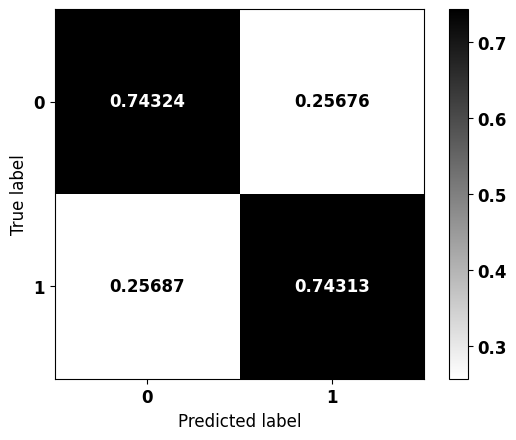


              precision    recall  f1-score   support

           0    0.48306   0.74324   0.58555      2033
           1    0.89962   0.74313   0.81392      6295

    accuracy                        0.74316      8328
   macro avg    0.69134   0.74318   0.69973      8328
weighted avg    0.79793   0.74316   0.75817      8328



In [ ]:
# Training the final XGBoost model using the best parameters
params = {'n_estimators': 114, 'max_depth': 4,
          'learning_rate': 0.2, 'gamma': 0.2,
          'min_child_weight': 3, 'colsample_bytree': 0.4,
          'random_state': 1, 'scale_pos_weight': 0.3004}

# Initializing the XGBoost classifier with optimized parameters
xgb_1year = XGBClassifier()
xgb_1year.set_params(**params)

# Training the optimized model on the training dataset
xgb_1year.fit(X_train_1year, y_train_1year)

# Plotting the confusion matrix to evaluate the model's performance on the test dataset
plot_confusion_matrix(xgb_1year, X_test_1year, y_test_1year)

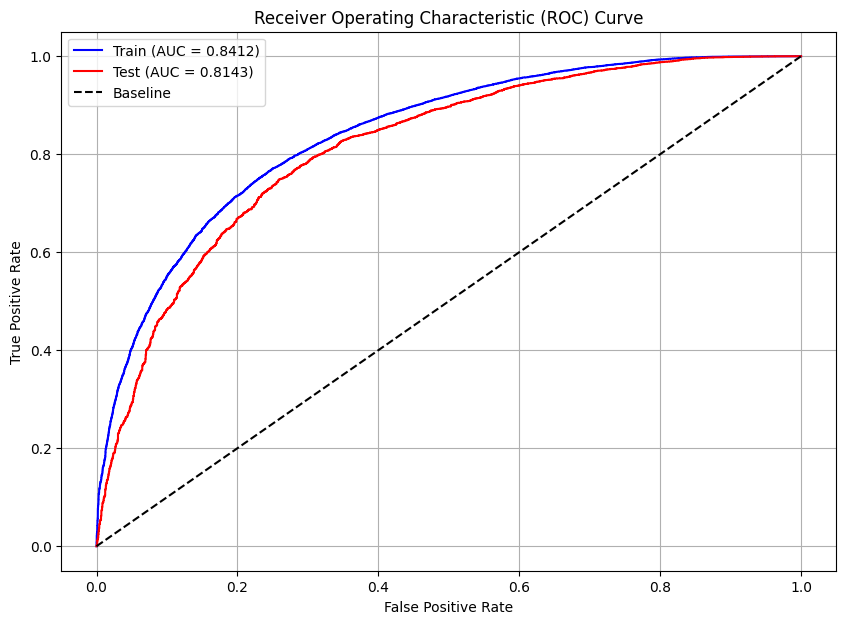

In [ ]:
# ROC Curve
# Plot the Receiver Operating Characteristic (ROC) curve
# to evaluate the model's performance in distinguishing between classes
plot_roc_curve(xgb_1year, X_train_1year, X_test_1year, y_train_1year, y_test_1year)

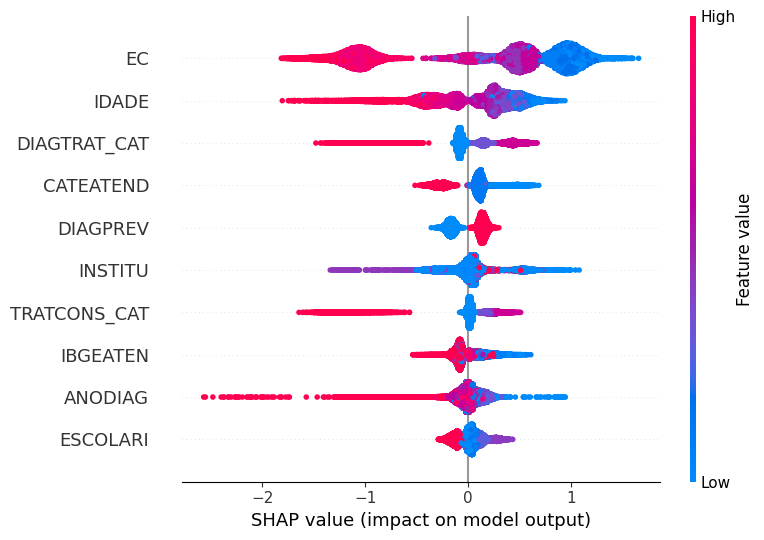

In [ ]:
# Feature Importance using SHAP values
# Plot the SHAP (SHapley Additive exPlanations) values
# to analyze the contribution of each feature to the model's predictions
plot_shap_values(xgb_1year, X_train_1year, feat_cols_1year)

## **3-Year Survival**

### **Preprocessing**

In [ ]:
# Colorectal Dataset
!gdown 1LghfTkwwW-UdecKL-Wsm8rY2zGWkYDWi --quiet

In [ ]:
# Reading Data
df_colo = pd.read_csv('colorretal.csv')
print(df_colo.shape)
df_colo.head(3)

(44857, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag
0,612374,9,91,2,3550308,2,2,C209,IIA,II,...,0,1,0,0,0,0,1,0,0,23
1,8,9,79,2,3550308,9,1,C180,II,II,...,0,0,0,0,0,0,1,1,1,61
2,8,9,59,2,3534401,9,2,C209,II,II,...,0,0,0,1,0,0,1,1,1,61


In [ ]:
df_colo = df_colo[~((df_colo.obito_geral == 0) & (df_colo.sobrevida_ano3 == 0))].reset_index(drop=True)  # Remove cases with unknown survival status
df_colo.shape

(36895, 49)

In [ ]:
# Data Splitting into Training and Testing Sets
# Separate features (X) and target variable (y)
X = df_colo.drop(['obito_geral'], axis=1)  # Features (all columns except 'obito_geral')
y = df_colo['obito_geral']  # Target variable ('obito_geral')

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  # 80% train, 20% test
                                                    random_state=seed,  # For reproducibility
                                                    stratify=y)  # Stratified sampling to maintain class proportions

# Print the shapes of the resulting datasets
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_train: (29516, 48)
y_train: (29516,)
X_test: (7379, 48)
y_test: (7379,)


In [ ]:
# Saving the Datasets
# Concatenate features and target variable for training and testing sets
df_treino = pd.concat([X_train, y_train], axis=1)  # Combine X_train and y_train into a single DataFrame
df_teste = pd.concat([X_test, y_test], axis=1)  # Combine X_test and y_test into a single DataFrame

df_treino.to_csv('colorretal_treino.csv', index=False) # Save the training DataFrame to 'colorretal_treino.csv'
df_teste.to_csv('colorretal_teste.csv', index=False)  # Save the testing DataFrame to 'colorretal_teste.csv'

In [ ]:
# Reading Training Data
df_treino = pd.read_csv('colorretal_treino.csv')  # Load the training data from the CSV file
print(df_treino.shape)  # Print the dimensions of the training DataFrame
df_treino.head(3)  # Display the first 3 rows of the training DataFrame

(29516, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,20141,2,67,2,3525904,2,2,C209,II,II,...,1,2,0,0,0,0,0,0,7,1
1,8672,9,70,1,3550308,9,1,C187,IV,IV,...,0,0,1,0,1,0,0,0,6,1
2,16772,9,75,1,3550308,9,1,C187,IV,IV,...,2,0,1,0,0,1,0,0,14,1


In [ ]:
# Reading Test Data
df_teste = pd.read_csv('colorretal_teste.csv')  # Load the test data from the CSV file
print(df_teste.shape)  # Print the dimensions of the test DataFrame
df_teste.head(3)  # Display the first 3 rows of the test DataFrame

(7379, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,8672,3,47,2,3550308,2,2,C209,IIA,II,...,0,1,0,0,0,1,1,1,61,0
1,208259,4,60,1,3548807,2,2,C209,III,III,...,0,0,0,0,0,1,1,0,47,0
2,18597,9,62,2,3548500,9,1,C209,III,III,...,0,0,0,0,1,0,0,0,5,1


In [ ]:
# Exclude the row where ULTDIAG is negative
df_treino = df_treino[df_treino.ULTIDIAG >= 0]

df_treino.shape

(29516, 49)

In [ ]:
# X train and test after removing unnecessary columns, including Death and Months from Diagnosis (which go to the target Y)
list_drop = ['ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO', 'HORMONIO',
             'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
             'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
             'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'RRAS', 'DSCINST', 'RRAS_INST',
             'ECGRUP_CAT', 'ULTIDIAG', 'CONSDIAG_CAT', 'PRESENCA_META',
             'PRESENCA_REC', 'obito_cancer', 'sobrevida_ano1', 'sobrevida_ano3',
             'sobrevida_ano5', 'meses_diag', 'obito_geral']

X_train_3year = df_treino.drop(list_drop, axis=1)  # Remove specified columns from the training dataset
y_train_3year = df_treino.sobrevida_ano3.copy()

X_test_3year = df_teste.drop(list_drop, axis=1)  # Remove specified columns from the test dataset
y_test_3year = df_teste.sobrevida_ano3.copy()

X_train_3year.shape, y_train_3year.shape, X_test_3year.shape, y_test_3year.shape

((29516, 16), (29516,), (7379, 16), (7379,))

In [ ]:
# Preprocessing of Training and Test data
X_train_3year, X_test_3year, feat_cols_3year, enc, norm = preprocessing(X_train_3year, X_test_3year,
                                                      norm_name='StandardScaler',  # Specify normalization method
                                                      return_enc_norm=True,  # Return encoder and normalizer objects
                                                      random_state=seed)  # Set random state for reproducibility

### **XGBoost**


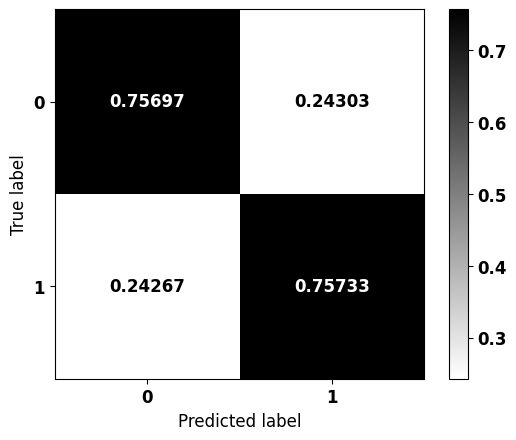


              precision    recall  f1-score   support

           0    0.76106   0.75697   0.75901      3728
           1    0.75320   0.75733   0.75526      3651

    accuracy                        0.75715      7379
   macro avg    0.75713   0.75715   0.75713      7379
weighted avg    0.75717   0.75715   0.75715      7379



In [ ]:
params = {'n_estimators': 150, 'max_depth': 5,
          'learning_rate': 0.2, 'gamma': 0.1,
          'min_child_weight': 1, 'colsample_bytree': 0.5,
          'random_state': 1, 'scale_pos_weight': 0.7986}

# Initializing the XGBoost classifier with optimized parameters
xgb_3year = XGBClassifier()
xgb_3year.set_params(**params)

# Training the optimized model on the training dataset
xgb_3year.fit(X_train_3year, y_train_3year)

# Plotting the confusion matrix to evaluate the model's performance on the test dataset
plot_confusion_matrix(xgb_3year, X_test_3year, y_test_3year)

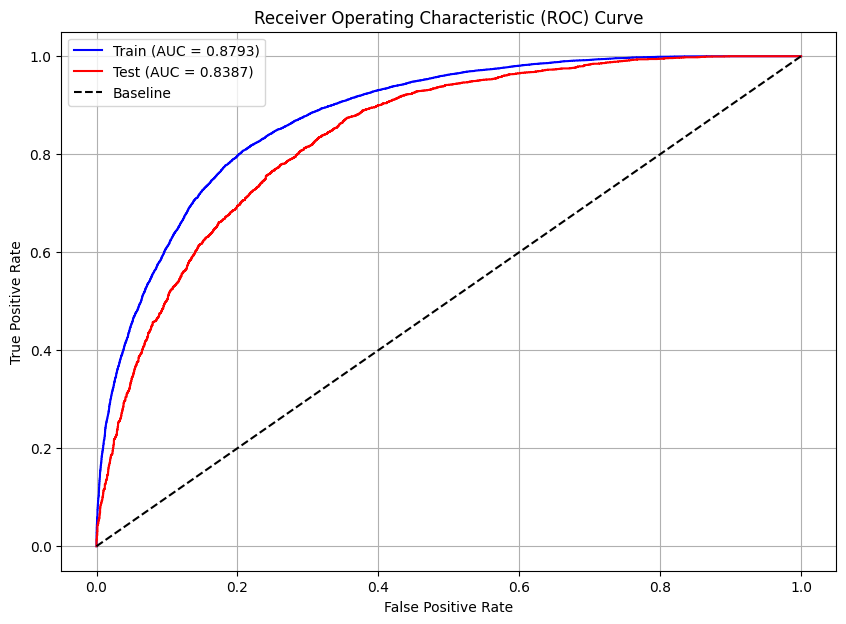

In [ ]:
# ROC Curve
# Plot the Receiver Operating Characteristic (ROC) curve
# to evaluate the model's performance in distinguishing between classes
plot_roc_curve(xgb_3year, X_train_3year, X_test_3year, y_train_3year, y_test_3year)

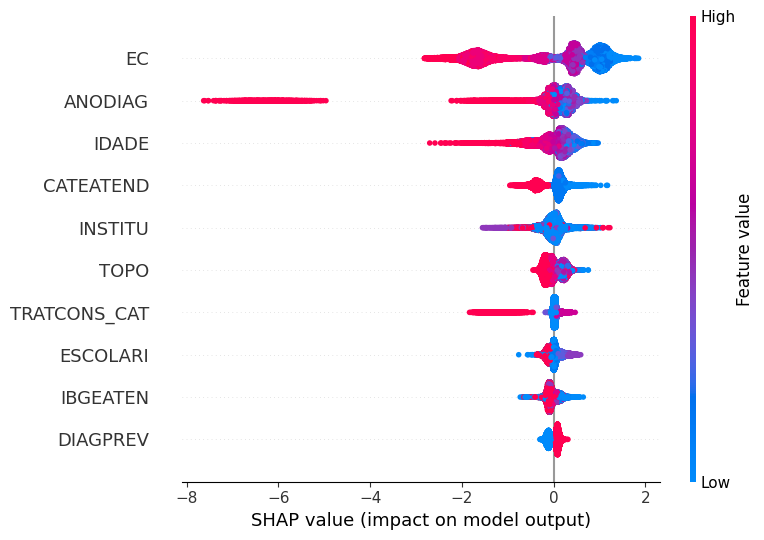

In [ ]:
# Feature Importance using SHAP values
# Plot the SHAP (SHapley Additive exPlanations) values
# to analyze the contribution of each feature to the model's predictions
plot_shap_values(xgb_3year, X_train_3year, feat_cols_3year)

## **5-Year Survival**

### **Preprocessing**

In [ ]:
# Colorectal Dataset
!gdown 1LghfTkwwW-UdecKL-Wsm8rY2zGWkYDWi --quiet

In [ ]:
# Reading Data
df_colo = pd.read_csv('colorretal.csv')
print(df_colo.shape)
df_colo.head(3)

(44857, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag
0,612374,9,91,2,3550308,2,2,C209,IIA,II,...,0,1,0,0,0,0,1,0,0,23
1,8,9,79,2,3550308,9,1,C180,II,II,...,0,0,0,0,0,0,1,1,1,61
2,8,9,59,2,3534401,9,2,C209,II,II,...,0,0,0,1,0,0,1,1,1,61


In [ ]:
df_colo = df_colo[~((df_colo.obito_geral == 0) & (df_colo.sobrevida_ano5 == 0))].reset_index(drop=True)  # Remove cases with unknown survival status
df_colo.shape

(33872, 49)

In [ ]:
# Data Splitting into Training and Testing Sets
# Separate features (X) and target variable (y)
X = df_colo.drop(['obito_geral'], axis=1)  # Features (all columns except 'obito_geral')
y = df_colo['obito_geral']  # Target variable ('obito_geral')

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  # 80% train, 20% test
                                                    random_state=seed,  # For reproducibility
                                                    stratify=y)  # Stratified sampling to maintain class proportions

# Print the shapes of the resulting datasets
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_train: (27097, 48)
y_train: (27097,)
X_test: (6775, 48)
y_test: (6775,)


In [ ]:
# Saving the Datasets
# Concatenate features and target variable for training and testing sets
df_treino = pd.concat([X_train, y_train], axis=1)  # Combine X_train and y_train into a single DataFrame
df_teste = pd.concat([X_test, y_test], axis=1)  # Combine X_test and y_test into a single DataFrame

df_treino.to_csv('colorretal_treino.csv', index=False) # Save the training DataFrame to 'colorretal_treino.csv'
df_teste.to_csv('colorretal_teste.csv', index=False)  # Save the testing DataFrame to 'colorretal_teste.csv'

In [ ]:
# Reading Training Data
df_treino = pd.read_csv('colorretal_treino.csv')  # Load the training data from the CSV file
print(df_treino.shape)  # Print the dimensions of the training DataFrame
df_treino.head(3)  # Display the first 3 rows of the training DataFrame

(27097, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,20435,3,60,1,3543907,9,2,C189,IIIB,III,...,0,1,0,0,1,1,0,0,14,1
1,8672,2,56,2,3550308,9,1,C182,II,II,...,0,0,0,0,0,1,1,1,61,0
2,16659,9,61,1,3507001,9,1,C209,III,III,...,0,0,0,0,1,1,0,0,35,1


In [ ]:
# Reading Test Data
df_teste = pd.read_csv('colorretal_teste.csv')  # Load the test data from the CSV file
print(df_teste.shape)  # Print the dimensions of the test DataFrame
df_teste.head(3)  # Display the first 3 rows of the test DataFrame

(6775, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,612374,3,76,1,3550308,9,2,C199,III,III,...,3,3,0,0,1,1,0,0,20,1
1,612374,2,64,2,3548708,9,2,C209,IIB,II,...,1,2,0,0,0,1,1,1,61,0
2,9385,9,66,2,3550308,2,1,C209,IIA,II,...,2,0,0,0,0,1,1,1,61,0


In [ ]:
# Exclude the row where ULTDIAG is negative
df_treino = df_treino[df_treino.ULTIDIAG >= 0]

df_treino.shape

(27097, 49)

In [ ]:
# X train and test after removing unnecessary columns, including Death and Months from Diagnosis (which go to the target Y)
list_drop = ['ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO', 'HORMONIO',
             'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
             'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
             'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'RRAS', 'DSCINST', 'RRAS_INST',
             'ECGRUP_CAT', 'ULTIDIAG', 'CONSDIAG_CAT', 'PRESENCA_META',
             'PRESENCA_REC', 'obito_cancer', 'sobrevida_ano1', 'sobrevida_ano3',
             'sobrevida_ano5', 'meses_diag', 'obito_geral']

X_train_5year = df_treino.drop(list_drop, axis=1)  # Remove specified columns from the training dataset
y_train_5year = df_treino.sobrevida_ano5.copy()

X_test_5year = df_teste.drop(list_drop, axis=1)  # Remove specified columns from the test dataset
y_test_5year = df_teste.sobrevida_ano5.copy()

X_train_5year.shape, y_train_5year.shape, X_test_5year.shape, y_test_5year.shape

((27097, 16), (27097,), (6775, 16), (6775,))

In [ ]:
# Preprocessing of Training and Test data
X_train_5year, X_test_5year, feat_cols_5year, enc, norm = preprocessing(X_train_5year, X_test_5year,
                                                      norm_name='StandardScaler',  # Specify normalization method
                                                      return_enc_norm=True,  # Return encoder and normalizer objects
                                                      random_state=seed)  # Set random state for reproducibility

### **XGBoost**


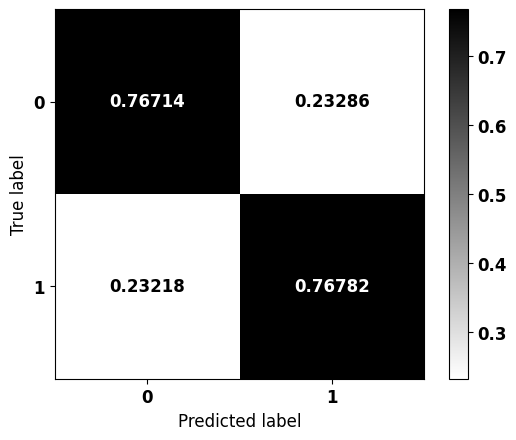


              precision    recall  f1-score   support

           0    0.85769   0.76714   0.80989      4376
           1    0.64383   0.76782   0.70038      2399

    accuracy                        0.76738      6775
   macro avg    0.75076   0.76748   0.75514      6775
weighted avg    0.78196   0.76738   0.77111      6775



In [ ]:
params = {'n_estimators': 137, 'max_depth': 5,
          'learning_rate': 0.15, 'gamma': 0.1,
          'min_child_weight': 6, 'colsample_bytree': 0.3,
          'random_state': 1, 'scale_pos_weight': 1.286}

# Initializing the XGBoost classifier with optimized parameters
xgb_5year = XGBClassifier()
xgb_5year.set_params(**params)

# Training the optimized model on the training dataset
xgb_5year.fit(X_train_5year, y_train_5year)

# Plotting the confusion matrix to evaluate the model's performance on the test dataset
plot_confusion_matrix(xgb_5year, X_test_5year, y_test_5year)

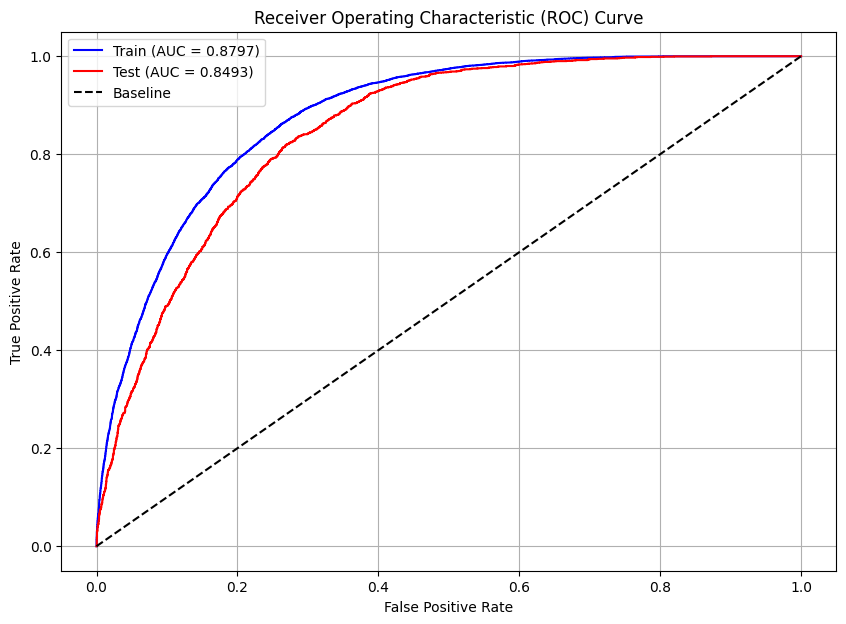

In [ ]:
# ROC Curve
# Plot the Receiver Operating Characteristic (ROC) curve
# to evaluate the model's performance in distinguishing between classes
plot_roc_curve(xgb_5year, X_train_5year, X_test_5year, y_train_5year, y_test_5year)

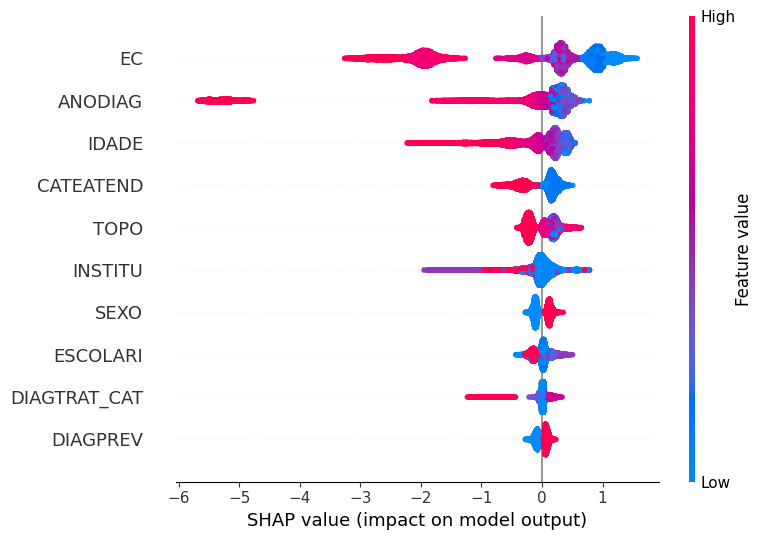

In [ ]:
# Feature Importance using SHAP values
# Plot the SHAP (SHapley Additive exPlanations) values
# to analyze the contribution of each feature to the model's predictions
plot_shap_values(xgb_5year, X_train_5year, feat_cols_5year)

# **Survival models**
Plot of the MLSA model curves.

## **Train and Test**

Dividing the database into training and testing components.

In [ ]:
# Colorectal Dataset
!gdown 1LghfTkwwW-UdecKL-Wsm8rY2zGWkYDWi --quiet

In [ ]:
# Reading Data
df_colo = pd.read_csv('colorretal.csv')
print(df_colo.shape)
df_colo.head(3)

(44857, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag
0,612374,9,91,2,3550308,2,2,C209,IIA,II,...,0,1,0,0,0,0,1,0,0,23
1,8,9,79,2,3550308,9,1,C180,II,II,...,0,0,0,0,0,0,1,1,1,61
2,8,9,59,2,3534401,9,2,C209,II,II,...,0,0,0,1,0,0,1,1,1,61


In [ ]:
# Columns
df_colo.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'TOPO', 'EC', 'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO',
       'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
       'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
       'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'ANODIAG', 'DRS', 'RRAS', 'DSCINST',
       'IBGEATEN', 'HABILIT2', 'DRS_INST', 'RRAS_INST', 'ECGRUP_CAT',
       'ULTIDIAG', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT',
       'PRESENCA_META', 'PRESENCA_REC', 'obito_geral', 'obito_cancer',
       'sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5', 'meses_diag'],
      dtype='object')

In [ ]:
# Overall Survival
df_colo['obito_geral'].value_counts()

,count
obito_geral,
0,22980
1,21877


In [ ]:
# Data Splitting into Training and Testing Sets
# Separate features (X) and target variable (y)
X = df_colo.drop(['obito_geral'], axis=1)  # Features (all columns except 'obito_geral')
y = df_colo['obito_geral']  # Target variable ('obito_geral')

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  # 80% train, 20% test
                                                    random_state=seed,  # For reproducibility
                                                    stratify=y)  # Stratified sampling to maintain class proportions

# Print the shapes of the resulting datasets
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_train: (35885, 48)
y_train: (35885,)
X_test: (8972, 48)
y_test: (8972,)


In [ ]:
# Saving the Datasets
# Concatenate features and target variable for training and testing sets
df_treino = pd.concat([X_train, y_train], axis=1)  # Combine X_train and y_train into a single DataFrame
df_teste = pd.concat([X_test, y_test], axis=1)  # Combine X_test and y_test into a single DataFrame

df_treino.to_csv('colorretal_treino.csv', index=False) # Save the training DataFrame to 'colorretal_treino.csv'
df_teste.to_csv('colorretal_teste.csv', index=False)  # Save the testing DataFrame to 'colorretal_teste.csv'

## **Kaplan-Meier**

The Kaplan-Meier method will be used as the baseline for comparison with the survival model curves.

In [ ]:
# Reading Test Data
df_teste = pd.read_csv('colorretal_teste.csv')  # Load the test data from the CSV file
print(df_teste.shape)  # Print the dimensions of the test DataFrame
df_teste.head(3)  # Display the first 3 rows of the test DataFrame

(8972, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,21636,2,67,1,3516705,2,1,C185,IIIB,III,...,1,0,0,0,0,1,1,1,61,0
1,19488,2,46,2,3552205,2,1,C188,IIIB,III,...,0,0,0,1,0,1,0,0,33,0
2,612374,2,66,2,3534401,9,2,C209,IIA,II,...,0,2,0,0,0,1,1,1,61,0


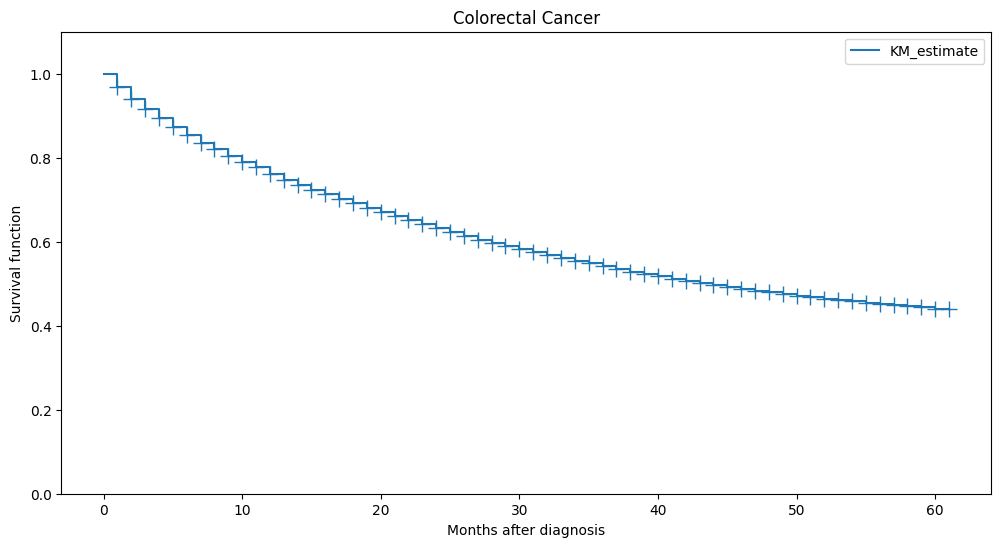

In [ ]:
# Kaplan-Meier Survival Curve Plot
# Extract event (E) and time (T) data from the test set
E = (df_teste.obito_geral == 1)  # Event indicator (obito_geral = 1 means event occurred)
T = df_teste.meses_diag  # Time to event (months since diagnosis)

title = f'Colorectal Cancer'  # Set the plot title

kmf = KaplanMeierFitter()  # Initialize the Kaplan-Meier fitter

fig = plt.figure(figsize=(12, 6))  # Create the plot figure
ax = plt.subplot(111)  # Create the axes for the plot

# Fit and plot the Kaplan-Meier survival curve
ax = kmf.fit(T, E).plot(ax=ax, ci_show=False, show_censors=True)  # Fit the model, plot the curve, show censoring marks
ax.set_title(title)  # Set the plot title
ax.set_xlabel('Months after diagnosis')  # Set the x-axis label
ax.set_ylabel('Survival function')  # Set the y-axis label
plt.ylim([0, 1.1])  # Set y-axis limits
plt.show()  # Display the plot

## **Machine Learning Survival**

Training of the 'best models' of the study, identified in the [survival models notebook](https://colab.research.google.com/drive/1KaVl92XBllE3STc4n1UwiZ_V50NdSvAW#scrollTo=HA7fWLKzc2P_).

### **Data preparation for survival models**

In [ ]:
# Reading Training Data
df_treino = pd.read_csv('colorretal_treino.csv')  # Load the training data from the CSV file
print(df_treino.shape)  # Print the dimensions of the training DataFrame
df_treino.head(3)  # Display the first 3 rows of the training DataFrame

(35885, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,22128,2,71,1,3549805,2,1,C186,IIA,II,...,0,0,0,0,0,0,0,0,1,1
1,16624,9,73,2,3550308,2,2,C209,IV,IV,...,2,2,1,0,1,1,0,0,26,1
2,16675,4,87,2,3550308,1,1,C209,IVB,IV,...,0,0,1,0,1,1,0,0,13,1


In [ ]:
# Reading Test Data
df_teste = pd.read_csv('colorretal_teste.csv')  # Load the test data from the CSV file
print(df_teste.shape)  # Print the dimensions of the test DataFrame
df_teste.head(3)  # Display the first 3 rows of the test DataFrame

(8972, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,21636,2,67,1,3516705,2,1,C185,IIIB,III,...,1,0,0,0,0,1,1,1,61,0
1,19488,2,46,2,3552205,2,1,C188,IIIB,III,...,0,0,0,1,0,1,0,0,33,0
2,612374,2,66,2,3534401,9,2,C209,IIA,II,...,0,2,0,0,0,1,1,1,61,0


In [ ]:
# Exclude the row where ULTDIAG is negative
df_treino = df_treino[df_treino.ULTIDIAG >= 0]

df_treino.shape

(35884, 49)

In [ ]:
# Y train and test for survival data (Death, Months from Diagnosis)
y_train = Surv.from_arrays(df_treino.obito_geral, df_treino.meses_diag)  # Create survival data for training set
y_test = Surv.from_arrays(df_teste.obito_geral, df_teste.meses_diag)  # Create survival data for test set

In [ ]:
# X train and test after removing unnecessary columns, including Death and Months from Diagnosis (which go to the target Y)
list_drop = ['obito_cancer', 'sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5',
             'meses_diag', 'obito_geral', 'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO',
             'QUIMIO', 'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS',
             'RADIOAPOS', 'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS',
             'ULTINFO', 'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'RRAS', 'DSCINST',
             'RRAS_INST', 'ECGRUP_CAT', 'ULTIDIAG', 'CONSDIAG_CAT', 'PRESENCA_META',
             'PRESENCA_REC']

X_train = df_treino.drop(list_drop, axis=1)  # Remove specified columns from the training dataset

X_test = df_teste.drop(list_drop, axis=1)  # Remove specified columns from the test dataset

In [ ]:
# Preprocessing of Training and Test data
X_train, X_test, feat_cols, enc, norm = preprocessing(X_train, X_test,
                                                      norm_name='StandardScaler',  # Specify normalization method
                                                      return_enc_norm=True,  # Return encoder and normalizer objects
                                                      random_state=seed)  # Set random state for reproducibility

# Display the shapes of the processed training and test datasets
X_train.shape, X_test.shape

((35884, 16), (8972, 16))

In [ ]:
# Features columns
feat_cols

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'TOPO', 'EC', 'ANODIAG', 'DRS', 'IBGEATEN', 'HABILIT2', 'DRS_INST',
       'TRATCONS_CAT', 'DIAGTRAT_CAT'],
      dtype='object')

### **Models**

**RSF**

C-Index Test: 0.7547371017603656
C-Index Train: 0.7797215136399612

C-Index IPCW Test: 0.7489074752081798
C-Index IPCW Train: 0.7734233170546442

Integrated Brier Score (IBS): 0.1564607924057264

Brier Score:
    > 1 year = 0.13744132278481827
    > 3 years = 0.17567015830959912
    > 5 years = 0.17596705641278645



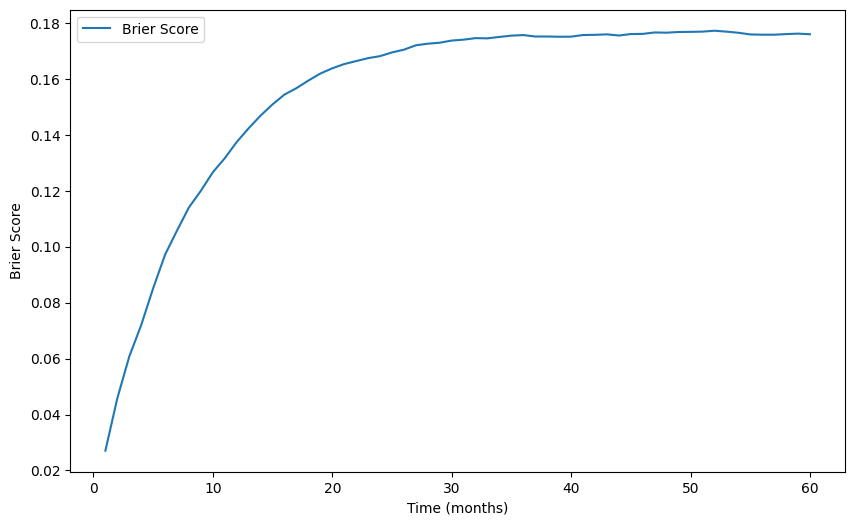

CPU times: user 33.4 s, sys: 1.07 s, total: 34.5 s
Wall time: 34.7 s


In [ ]:
%%time

rsf = RandomSurvivalForest(bootstrap=False, max_depth=10, max_features='log2',
                     min_samples_leaf=9, min_samples_split=9, n_estimators=116,
                     random_state=1)
rsf.fit(X_train, y_train)

# Metrics of the best RSF model
final_c_index = rsf.score(X_test, y_test)  # Compute the final C-index for the test dataset

# Print the C-index for both test and training datasets
print(f'C-Index Test: {final_c_index}')
print(f'C-Index Train: {rsf.score(X_train, y_train)}\n')

# Compute and display the IPCW C-index and Brier Score for the best model
c_index_ipcw_brier_score(rsf, X_train, y_train, X_test, y_test)

Mean AUC: 0.81974



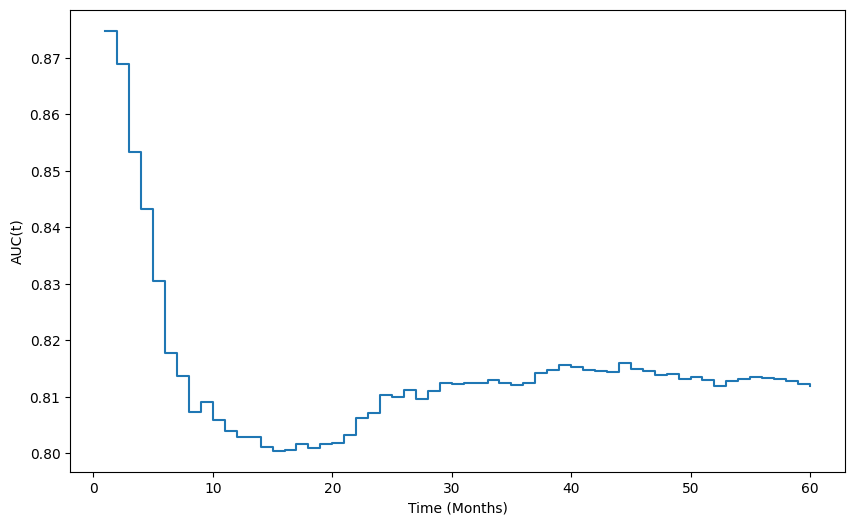

In [ ]:
from sksurv.metrics import cumulative_dynamic_auc

# Times to evaluate
times_eval = rsf.unique_times_[:-1]

# Model prediction
est_rsf = rsf.predict_cumulative_hazard_function(X_test, return_array=False)
rsf_risk_scores = np.vstack([chf(times_eval) for chf in est_rsf])

# Cumulative/dynamic AUC calculation
auc_rsf_times, mean_auc_rsf = cumulative_dynamic_auc(y_train, y_test, rsf_risk_scores, times_eval)

print(f'Mean AUC: {mean_auc_rsf:.5f}\n')

# Plot (AUC vs time)
plt.figure(figsize=(10, 6))
plt.step(times_eval, auc_rsf_times, where="post", label="RSF")
plt.xlabel("Time (Months)")
plt.ylabel("AUC(t)")
plt.show()

**Gradient Boosting Survival**

C-Index Test: 0.7588309162059692
C-Index Train: 0.7769290502442211

C-Index IPCW Test: 0.7525671954132044
C-Index IPCW Train: 0.7699414656611409

Integrated Brier Score (IBS): 0.15518065181192547

Brier Score:
    > 1 year = 0.13696842471438048
    > 3 years = 0.17350604846071546
    > 5 years = 0.17530808938267675



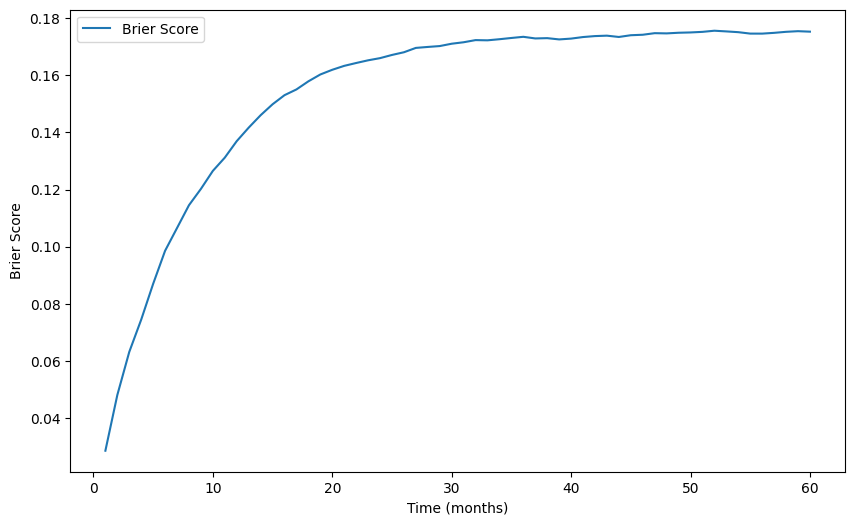

CPU times: user 36min 59s, sys: 1.14 s, total: 37min
Wall time: 37min 26s


In [ ]:
%%time

gb = GradientBoostingSurvivalAnalysis(learning_rate=0.2, max_depth=5,
                                 max_features=0.5, min_samples_leaf=6,
                                 min_samples_split=5, n_estimators=111,
                                 random_state=1, subsample=0.9)
gb.fit(X_train, y_train)

# Metrics of the best GBS model
final_c_index = gb.score(X_test, y_test)  # Compute the C-index for the best model on the test dataset

print(f'C-Index Test: {final_c_index}')  # Print the C-index for the test set
print(f'C-Index Train: {gb.score(X_train, y_train)}\n')  # Print the C-index for the training set

# Calculate and print the IPCW and Brier score for the best model
c_index_ipcw_brier_score(gb, X_train, y_train, X_test, y_test)

Mean AUC: 0.80372



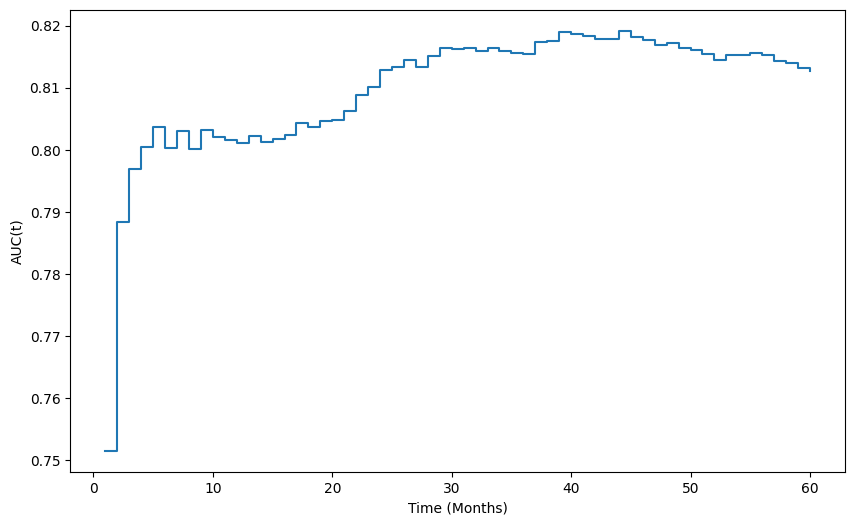

In [ ]:
# Times to evaluate
times_eval = gb.unique_times_[:-1]

# Model prediction
est_gb = gb.predict_cumulative_hazard_function(X_test, return_array=False)
gb_risk_scores = np.vstack([chf(times_eval) for chf in est_gb])

# Cumulative/dynamic AUC calculation
auc_gb_times, mean_auc_gb = cumulative_dynamic_auc(y_train, y_test, gb_risk_scores, times_eval)

print(f'Mean AUC: {mean_auc_gb:.5f}\n')

# Plot (AUC vs time)
plt.figure(figsize=(10, 6))
plt.step(times_eval, auc_gb_times, where="post", label="GBSA")
plt.xlabel("Time (Months)")
plt.ylabel("AUC(t)")
plt.show()

**Survival SVM**

In [ ]:
%%time

ssvm = FastSurvivalSVM(optimizer='avltree', random_state=1)
ssvm.fit(X_train, y_train)

# C-Index Calculation
print('C-Index')
print(f'> Test: {ssvm.score(X_test, y_test)}')  # Calculate and print the C-index for the test set
print(f'> Train: {ssvm.score(X_train, y_train)}')  # Calculate and print the C-index for the training set

# C-Index IPCW Calculation
surv_risks = ssvm.predict(X_test)  # Predict survival risks for the test set
surv_risks_train = ssvm.predict(X_train)  # Predict survival risks for the training set

# Compute IPCW C-index for test and train sets
c_index_ipcw = concordance_index_ipcw(y_train, y_test, surv_risks)  # IPCW C-index for the test set
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, surv_risks_train)  # IPCW C-index for the train set

print('\nC-Index IPCW')
print(f'> Test: {c_index_ipcw[0]}')  # Print the IPCW C-index for the test set
print(f'> Train: {c_index_ipcw_train[0]}')  # Print the IPCW C-index for the training set

C-Index
> Test: 0.7088418088812972
> Train: 0.7140363897668406

C-Index IPCW
> Test: 0.7035689517806477
> Train: 0.7080728430532487
CPU times: user 20.8 s, sys: 29.6 ms, total: 20.8 s
Wall time: 19.5 s


Mean AUC: 0.74584



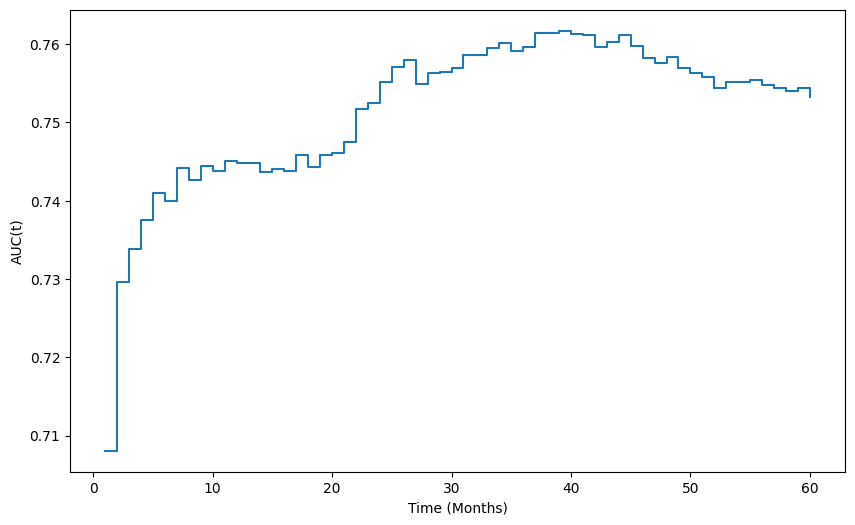

In [ ]:
# Times to evaluate
times_eval = rsf.unique_times_[:-1]

# Model prediction
est_ssvm = ssvm.predict(X_test)

# Cumulative/dynamic AUC calculation
auc_ssvm_times, mean_auc_ssvm = cumulative_dynamic_auc(y_train, y_test, est_ssvm, times_eval)

print(f'Mean AUC: {mean_auc_ssvm:.5f}\n')

# Plot (AUC vs time)
plt.figure(figsize=(10, 6))
plt.step(times_eval, auc_ssvm_times, where="post", label="SSVM")
plt.xlabel("Time (Months)")
plt.ylabel("AUC(t)")
plt.show()

Curve adaptation (through Cox model calibration).

Brier Score at 12 months: 0.1549586946491249
Brier Score at 36 months: 0.19824470036319844
Brier Score at 60 months: 0.2013479972521965

Integrated Brier Score (IBS): 0.1773698437603265


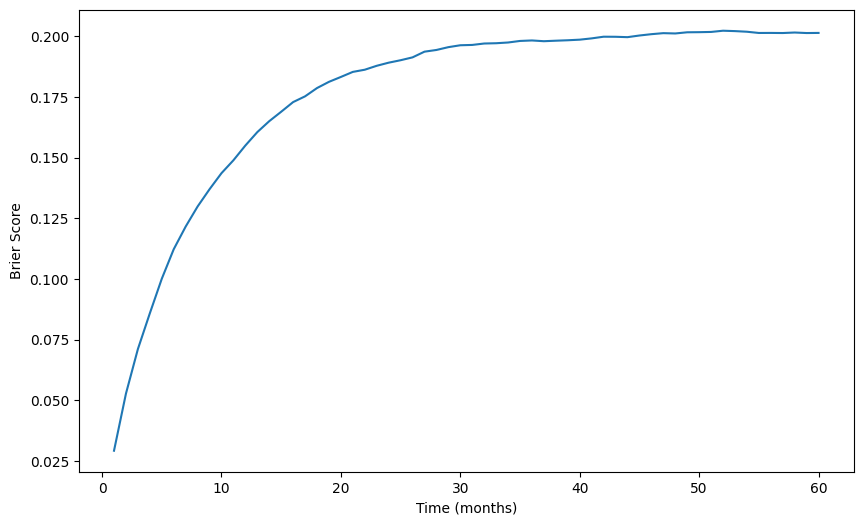

In [ ]:
from lifelines import CoxPHFitter
from sksurv.util import Surv

#Preparing dataframe for Cox Model training
event = y_test["event"]
time = y_test["time"]
df_cox = pd.DataFrame({
    "time": time,
    "event": event,
    "ssvm_score": surv_risks
})

#Fitting the Cox model with the predicted score as a covariate
cox = CoxPHFitter()
cox.fit(df_cox, duration_col="time", event_col="event")

# Generating individual curves (each column is a patient)
surv_funcs = cox.predict_survival_function(df_cox)
surv_funcs.drop(surv_funcs.index[-1], axis=0, inplace=True) #Censoring month 61
surv_ssvm_mean = surv_funcs.mean(axis=1)

#Brier Scores and Integrated Brier Score

time_points = np.arange(1, 61, 1)
surv_preds = surv_funcs.values.T

brier_scores = brier_score(
    y_train,  # Training data is used to estimate the censoring distribution
    y_test,   # Test data
    surv_preds,
    time_points
)

ibs = integrated_brier_score(
    y_train,
    y_test,
    surv_preds,
    time_points)

print(f"Brier Score at 12 months: {brier_scores[1][11]}")
print(f"Brier Score at 36 months: {brier_scores[1][35]}")
print(f"Brier Score at 60 months: {brier_scores[1][59]}")
print(f"\nIntegrated Brier Score (IBS): {ibs}")

# Plot the Brier Score over time
plt.figure(figsize=(10, 6))
plt.plot(time_points, brier_scores[1])
plt.xlabel("Time (months)")
plt.ylabel("Brier Score")
plt.show()

**XGBoost - Cox**

In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.25)  # Assign higher weights to events (1.0 for event and 0.25 for non-event)

params =  {'n_estimators': 73, 'learning_rate': 0.15, 'max_depth': 4, 'min_child_weight': 4,
           'subsample': 0.85, 'colsample_bytree': 0.6, 'reg_alpha': 1, 'reg_lambda': 0.01} # Get the best parameters from the study
params.update({'objective': 'survival:cox',  # Cox loss function for survival analysis
                    'eval_metric': 'cox-nloglik',  # Evaluation metric for Cox model
                    'random_state': seed,  # Set the random seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train, label=y_train['time'], weight=weights)  # DMatrix for training with weights
dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_cox = xgb.train(params, dtrain, num_boost_round=100,
                     verbose_eval=False)

# Make predictions on the test and training datasets
y_pred = xgb_cox.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_cox.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index = concordance_index_censored(y_test['event'], y_test['time'], y_pred)[0]  # C-Index for test
c_index_train = concordance_index_censored(y_train['event'], y_train['time'], y_pred_train)[0]  # C-Index for train

print('C-Index')  # Print label for C-Index
print(f'> Test: {c_index}')  # Print C-Index for the test set
print(f'> Train: {c_index_train}')  # Print C-Index for the training set

c_index_ipcw = concordance_index_ipcw(y_train, y_test, y_pred)  # C-Index IPCW for the test set
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, y_pred_train)  # C-Index IPCW for the training set

print('\nC-Index IPCW')  # Print label for C-Index IPCW
print(f'> Test: {c_index_ipcw[0]}')  # Print IPCW C-Index for the test set
print(f'> Train: {c_index_ipcw_train[0]}')  # Print IPCW C-Index for the training set

C-Index
> Test: 0.7239723543823222
> Train: 0.7372687445273292

C-Index IPCW
> Test: 0.7183988956881996
> Train: 0.7302338923259778


Mean AUC: 0.79375



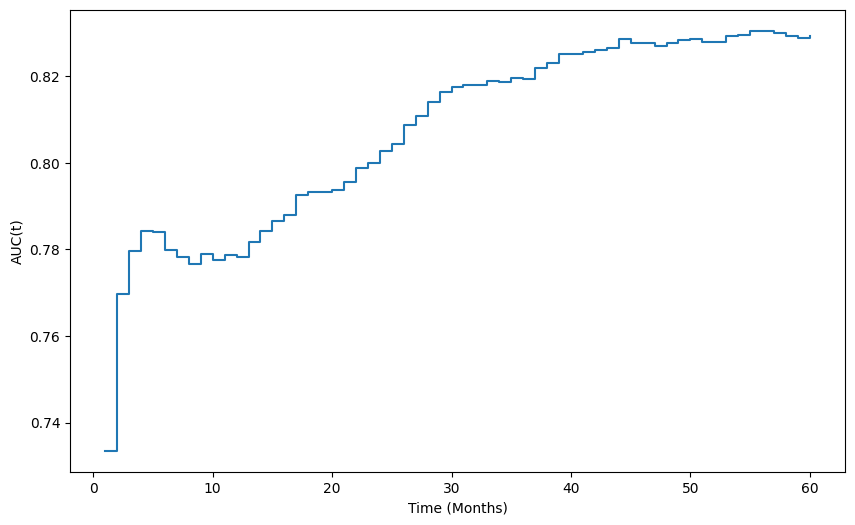

In [ ]:
# Times to evaluate
times_eval = rsf.unique_times_[:-1]

# Model prediction
y_pred = xgb_cox.predict(dtest)

# Cumulative/dynamic AUC calculation
auc_xgbc_times, mean_auc_xgbc = cumulative_dynamic_auc(y_train, y_test, y_pred, times_eval)

print(f'Mean AUC: {mean_auc_xgbc:.5f}\n')

# Plot (AUC vs time)
plt.figure(figsize=(10, 6))
plt.step(times_eval, auc_xgbc_times, where="post", label="XGB-Cox")
plt.xlabel("Time (Months)")
plt.ylabel("AUC(t)")
plt.show()

**XGBoost - AFT**

In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.65)  # Assign higher weights to events (1.0 for event and 0.65 for non-event)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

params = {'n_estimators': 71, 'learning_rate': 0.24, 'max_depth': 4, 'min_child_weight': 7,
               'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': 0.001, 'reg_lambda': 1, 'aft_loss_distribution': 'normal',
               'aft_loss_distribution_scale': 1.75}  # Get the best parameters from the study
params.update({'objective': 'survival:aft',  # AFT loss function for survival analysis
                    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
                    'random_state': seed,  # Seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)  # DMatrix for training with weights

dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_aft = xgb.train(params, dtrain, num_boost_round=100)

# Make predictions on the test and training datasets
y_pred = xgb_aft.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_aft.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for test
c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for train

print('C-Index')  # Print label for C-Index
print(f'> Test: {c_index}')  # Print C-Index for the test set
print(f'> Train: {c_index_train}')  # Print C-Index for the training set

c_index_ipcw = concordance_index_ipcw(y_train, y_test, -y_pred)  # C-Index IPCW for the test set
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -y_pred_train)  # C-Index IPCW for the training set

print('\nC-Index IPCW')  # Print label for C-Index IPCW
print(f'> Test: {c_index_ipcw[0]}')  # Print IPCW C-Index for the test set
print(f'> Train: {c_index_ipcw_train[0]}')  # Print IPCW C-Index for the training set

C-Index
> Test: 0.7617986988966732
> Train: 0.7811839221420257

C-Index IPCW
> Test: 0.7531615637628547
> Train: 0.7712038798077203


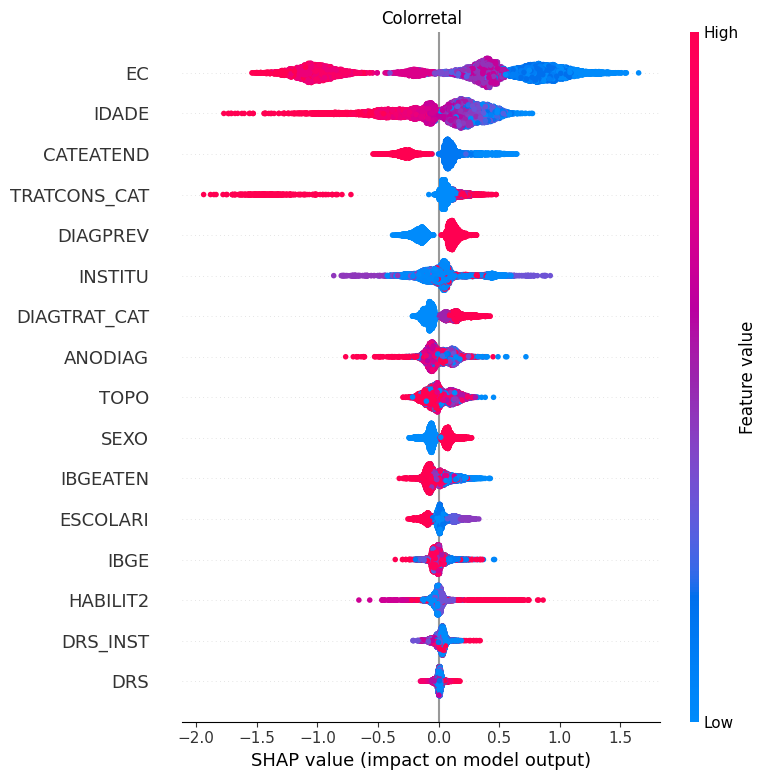

In [ ]:
# Create a SHAP TreeExplainer for the best model
explainer = shap.TreeExplainer(xgb_aft)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

plt.title('Colorretal')
# Generate a summary plot to visualize the SHAP values for each feature
shap.summary_plot(shap_values, X_test, feature_names=feat_cols, show=False)

plt.tight_layout()
plt.savefig("colorretal.svg");

Gráfico - Permutation Importance e SHAP

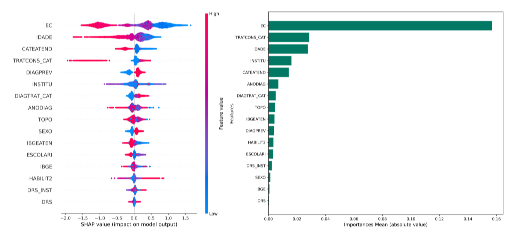

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.image as mpimg

# Best features by permutation importance
permutation_importance = calculate_permutation_importance_xgb(xgb_aft, X_test, y_test, feat_cols, random_state=seed)

# Create a SHAP TreeExplainer for the best model
explainer = shap.TreeExplainer(xgb_aft)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Save the SHAP summary_plot to a temporary file
shap.summary_plot(shap_values, X_test, feature_names=feat_cols, show=False)
plt.tight_layout()
plt.savefig("shap_plot.png", dpi=600, bbox_inches='tight')
plt.close()

# If 'feature' is in index, reset to column
if permutation_importance.index.name is not None:
    permutation_importance = permutation_importance.reset_index()

permutation_importance['features'] = permutation_importance.index

# Plot and save bar chart of your table
fig, ax = plt.subplots(figsize=(10,8))
permutation_importance_sorted = permutation_importance.sort_values('importances_mean', ascending=False)
ax.barh(permutation_importance_sorted['features'], permutation_importance_sorted['importances_mean'].abs(), color='#007863')
ax.set_xlabel('Importances Mean (absolute value)', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
# ax.set_title("Permutation Importance em módulo")
# fig.text(0.5, -0.02, 'Importances Mean (absolute value)', ha='center', fontsize=14)
# ax.invert_yaxis()  # mantém o mais importante no topo
plt.tight_layout()
plt.savefig("bar_plot.png", dpi=600, bbox_inches='tight')
plt.close()

# Open and combine images side by side with PIL
img1 = Image.open("shap_plot.png").convert("RGB")
img2 = Image.open("bar_plot.png").convert("RGB")

# Resize the height of the second image to match the height of the first (if necessary)
if img1.height != img2.height:
    img2 = img2.resize((img2.width, img1.height))

# Ensure same height
max_height = max(img1.height, img2.height)
total_width = img1.width + img2.width

# New combined image
combined_img = Image.new('RGB', (total_width, max_height), color=(255, 255, 255))
combined_img.paste(img1, (0, 0))
combined_img.paste(img2, (img1.width, 0))

# Save
combined_img.save("PI_SHAP_colorectal_charts.png", dpi=(300, 300), quality=95, optimize=True)
# combined_img.save("PI_SHAP_colorectal_charts.eps", dpi=(300, 300), quality=95, optimize=True)

img = mpimg.imread("PI_SHAP_colorectal_charts.png")
plt.imshow(img)
plt.axis('off')
plt.show()

**LightGBM**

In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.15)  # Assign weights based on event occurrence (1.0 for events, 0.15 for censored data)

# Update the best parameters with the required model settings
params = {'n_estimators': 110, 'learning_rate': 0.11, 'max_depth': 5, 'num_leaves': 23, 'min_child_samples': 14,
          'subsample': 0.6, 'colsample_bytree': 0.5, 'reg_alpha': 10.0, 'reg_lambda': 0.01}

params.update({'objective': 'regression',  # Use regression (Cox model) for survival analysis
                    'metric': 'rmse',  # Metric for monitoring performance (Root Mean Squared Error)
                    'seed': seed,  # Set the random seed for reproducibility
                    'verbose': -1,  # Suppress output during training
                    'n_jobs': -1})  # Use all available CPU cores for parallel computation

# Create the LightGBM dataset using the training data and weights
dtrain = lgb.Dataset(X_train, label=y_train['time'], weight=weights)
# dtest = xgb.DMatrix(X_test)  # You could use this for testing if needed, but it's not used here

# Train the LightGBM model with the best parameters found by Optuna
lgbm = lgb.train(params, dtrain, num_boost_round=100)

# Make predictions on the validation and training sets
y_pred = lgbm.predict(X_test)  # Predictions for the test set
y_pred_train = lgbm.predict(X_train)  # Predictions for the training set

# Calculate the Concordance Index (C-Index) for the test set
c_index = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]
c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

print('C-Index')
print(f'> Test: {c_index}')  # Print the C-Index for the test set
print(f'> Train: {c_index_train}')  # Print the C-Index for the training set

# Calculate IPCW C-Index
c_index_ipcw = concordance_index_ipcw(y_train, y_test, -y_pred)  # Compute IPCW C-Index for the test set
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -y_pred_train)  # Compute IPCW C-Index for the training set

# Display IPCW C-Index results
print('\nC-Index IPCW')
print(f'> Test: {c_index_ipcw[0]}')  # Print IPCW C-Index for the test set
print(f'> Train: {c_index_ipcw_train[0]}')  # Print IPCW C-Index for the training set

C-Index
> Test: 0.7274680720718807
> Train: 0.7440293719234166

C-Index IPCW
> Test: 0.7210504695773766
> Train: 0.7344669243598438


In [ ]:
colorretal = {
    'rsf': rsf,
    'gb': gb,
    'ssvm': ssvm,
    'xgb_cox': xgb_cox,
    'xgb_aft': xgb_aft
}

with open('colorretal.pkl', 'wb') as f:
    pickle.dump(colorretal, f)

In [ ]:
with open('colorretal.pkl', 'rb') as f:
    colorretal = pickle.load(f)

colorretal

{'rsf': RandomSurvivalForest(bootstrap=False, max_depth=10, max_features='log2',
                      min_samples_leaf=9, min_samples_split=9, n_estimators=116,
                      random_state=1),
 'gb': GradientBoostingSurvivalAnalysis(learning_rate=0.2, max_depth=5,
                                  max_features=0.5, min_samples_leaf=6,
                                  min_samples_split=5, n_estimators=111,
                                  random_state=1, subsample=0.9),
 'ssvm': FastSurvivalSVM(optimizer='avltree', random_state=1),
 'xgb_cox': <xgboost.core.Booster at 0x7a7a64594740>,
 'xgb_aft': <xgboost.core.Booster at 0x7a7a64684830>}

# **Curves**
Plot of initial and final curves (with and without classification models' predictions).

**Initial plot of the survival model curves along with the Kaplan-Meier statistical method**

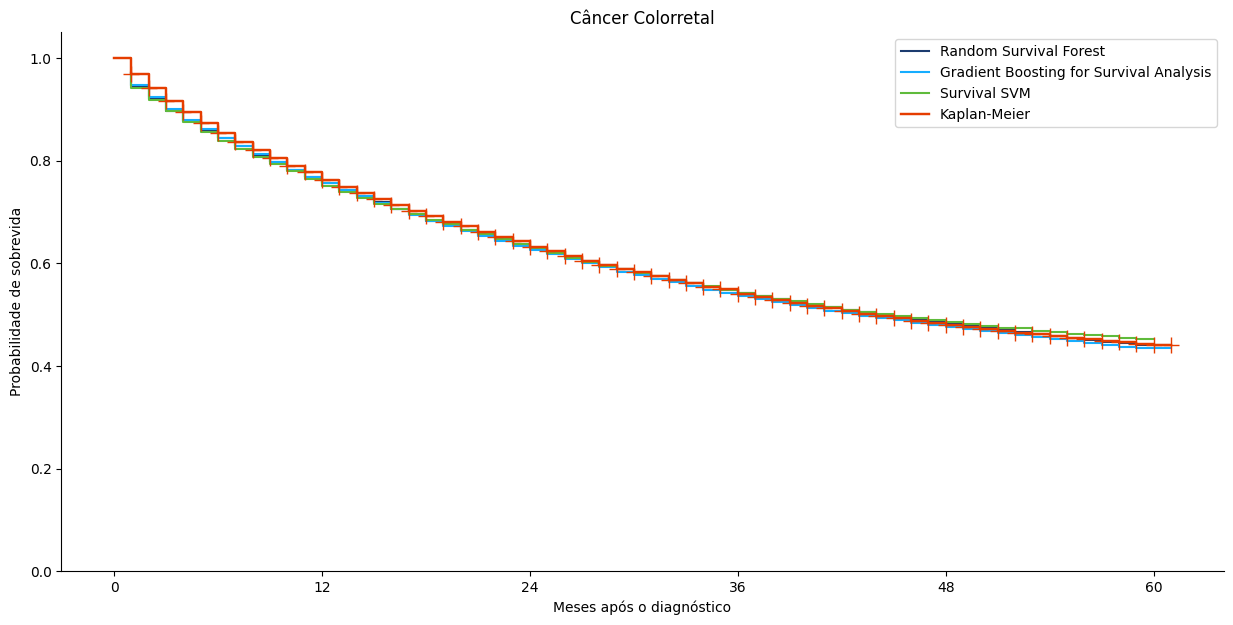

In [ ]:
# # KM
# fig = plt.figure(figsize=(15, 7))
# ax = plt.subplot(111)

# E = (df_teste.obito_geral == 1)  # Event indicator (obito_geral = 1 means event occurred)
# T = df_teste.meses_diag  # Time to event (months since diagnosis)

# colors = ['#E53D00',
#           '#15ADFF',
#           '#1B3B6F',
#           '#5FBB3B',
#           '#204026']

# times = rsf.unique_times_
# lstyle = 'solid'

# surv_rsf = rsf.predict_survival_function(X_test, return_array=True)
# surv_rsf_mean = surv_rsf.mean(axis=0)
# ax.step(times, surv_rsf_mean, linestyle=lstyle, color=colors[2],
#         label='Random Survival Forest')

# surv_gb = gb.predict_survival_function(X_test, return_array=True)
# surv_gb_mean = surv_gb.mean(axis=0)
# ax.step(times, surv_gb_mean, linestyle=lstyle, color=colors[1],
#         label='Gradient Boosting for Survival Analysis')

# # surv_ssvm_mean = surv_ssvm_final.mean(axis=0)
# ax.step(times[:-1], surv_ssvm_mean, linestyle=lstyle, color=colors[3],
#         label='Survival SVM')

# ax = kmf.fit(T, E).plot(ax=ax, ci_show=False, show_censors=True,
#                         label='Kaplan-Meier', color=colors[0],
#                         linewidth=1.75)

# # pred_1year = xgb_1year.predict(X_test_1year)
# # prop_1year = pred_1year.sum()/X_test_1year.shape[0]
# # ax.scatter(12, prop_1year, label='1-year survival - XGBoost Classifier', color=colors[4], marker='x')

# # pred_3year = xgb_3year.predict(X_test_3year)
# # prop_3year = pred_3year.sum()/X_test_3year.shape[0]
# # ax.scatter(36, prop_3year, label='3-year survival - XGBoost Classifier', color=colors[4], marker='x')

# # pred_5year = xgb_5year.predict(X_test_5year)
# # prop_5year = pred_5year.sum()/X_test_5year.shape[0]
# # ax.scatter(60, prop_5year, label='5-year survival - XGBoost Classifier', color=colors[4], marker='x')

# title = f'Câncer Colorretal'  # Set the plot title
# ax.set_title(title)
# ax.set_xlabel('Meses após o diagnóstico')
# ax.set_ylabel('Probabilidade de sobrevida')
# ax.spines['top'].set_visible(False)  # Remove top border
# ax.spines['right'].set_visible(False)  # Remove right border
# plt.xticks(np.arange(0, rsf.unique_times_[-1] + 11, 12))  # Set x-axis ticks every 12 months
# plt.ylim([0, 1.05])
# plt.legend()

# plt.savefig('colorretal.svg')

**Predictions from the classification models**

In [ ]:
pred_1year = xgb_1year.predict(X_test_1year)
prop_1year = pred_1year.sum()/X_test_1year.shape[0]

pred_3year = xgb_3year.predict(X_test_3year)
prop_3year = pred_3year.sum()/X_test_3year.shape[0]

pred_5year = xgb_5year.predict(X_test_5year)
prop_5year = pred_5year.sum()/X_test_5year.shape[0]

print(f'1-year survival - XGBoost Classifier: {prop_1year:.4f}')
print(f'3-year survival - XGBoost Classifier: {prop_3year:.4f}')
print(f'5-year survival - XGBoost Classifier: {prop_5year:.4f}')

1-year survival - XGBoost Classifier: 0.6244
3-year survival - XGBoost Classifier: 0.4975
5-year survival - XGBoost Classifier: 0.4223


**Final plot of the survival model curves, along with the Kaplan-Meier statistical method and predictions from classification models**

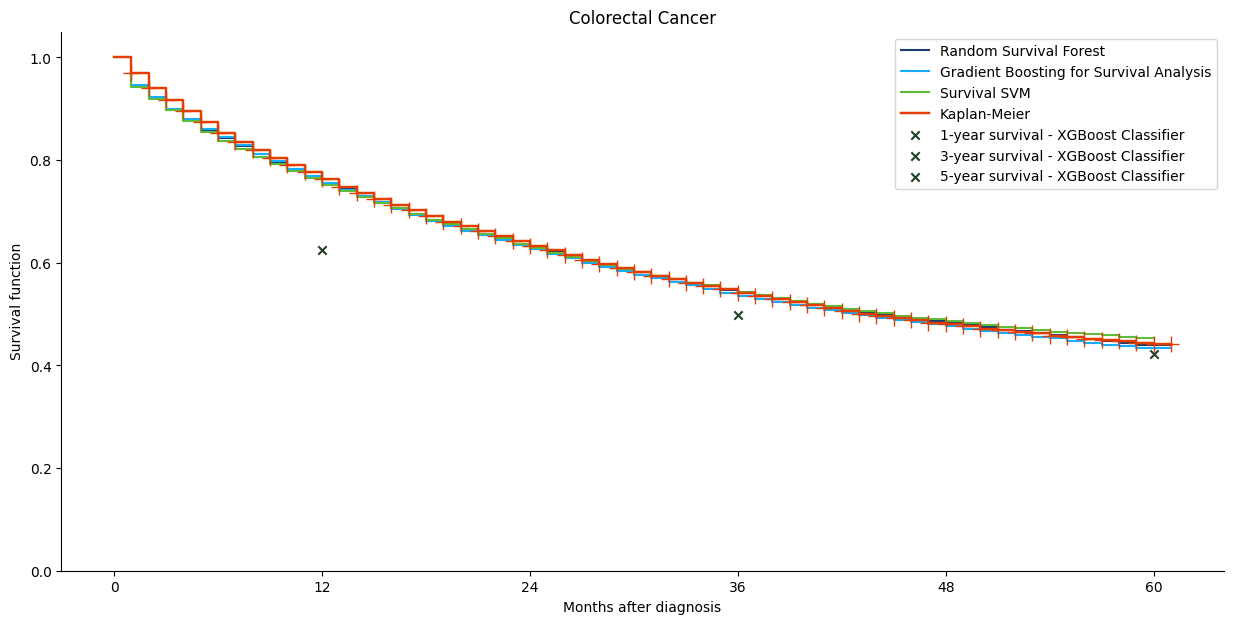

In [ ]:
# KM
fig = plt.figure(figsize=(15, 7))
ax = plt.subplot(111)

E = (df_teste.obito_geral == 1)  # Event indicator (obito_geral = 1 means event occurred)
T = df_teste.meses_diag  # Time to event (months since diagnosis)

colors = ['#E53D00',
          '#15ADFF',
          '#1B3B6F',
          '#5FBB3B',
          '#204026']

times = rsf.unique_times_
lstyle = 'solid'

surv_rsf = rsf.predict_survival_function(X_test, return_array=True)
surv_rsf_mean = surv_rsf.mean(axis=0)
ax.step(times, surv_rsf_mean, linestyle=lstyle, color=colors[2],
        label='Random Survival Forest')

surv_gb = gb.predict_survival_function(X_test, return_array=True)
surv_gb_mean = surv_gb.mean(axis=0)
ax.step(times, surv_gb_mean, linestyle=lstyle, color=colors[1],
        label='Gradient Boosting for Survival Analysis')

# surv_ssvm_mean = surv_ssvm_final.mean(axis=0)
ax.step(times[:-1], surv_ssvm_mean, linestyle=lstyle, color=colors[3],
        label='Survival SVM')

ax = kmf.fit(T, E).plot(ax=ax, ci_show=False, show_censors=True,
                        label='Kaplan-Meier', color=colors[0],
                        linewidth=1.75)

pred_1year = xgb_1year.predict(X_test_1year)
prop_1year = pred_1year.sum()/X_test_1year.shape[0]
ax.scatter(12, prop_1year, label='1-year survival - XGBoost Classifier', color=colors[4], marker='x')

pred_3year = xgb_3year.predict(X_test_3year)
prop_3year = pred_3year.sum()/X_test_3year.shape[0]
ax.scatter(36, prop_3year, label='3-year survival - XGBoost Classifier', color=colors[4], marker='x')

pred_5year = xgb_5year.predict(X_test_5year)
prop_5year = pred_5year.sum()/X_test_5year.shape[0]
ax.scatter(60, prop_5year, label='5-year survival - XGBoost Classifier', color=colors[4], marker='x')

title = f'Colorectal Cancer'  # Set the plot title
ax.set_title(title)
ax.set_xlabel('Months after diagnosis')
ax.set_ylabel('Survival function')
ax.spines['top'].set_visible(False)  # Remove top border
ax.spines['right'].set_visible(False)  # Remove right border
plt.xticks(np.arange(0, rsf.unique_times_[-1] + 11, 12))  # Set x-axis ticks every 12 months
plt.ylim([0, 1.05])
plt.legend()

plt.savefig('colorectal.eps')

In [ ]:
from google.colab import files
files.download("colorectal.eps")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Results**
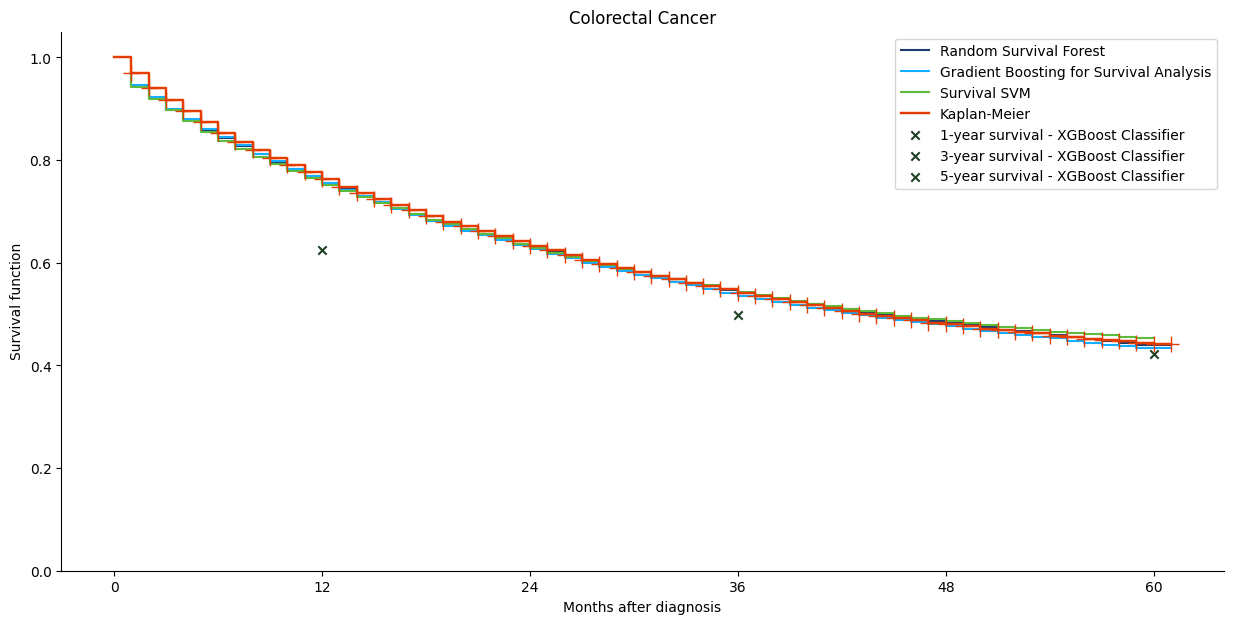

## Requirements Synchronization

In [ ]:
sync("ml", ["xgboost", "lightgbm", "scipy"])

[OK] xgboost já registrado (3.2.0)
[OK] lightgbm já registrado (4.6.0)
[OK] scipy já registrado (1.16.3)

Nenhuma alteração realizada.
